<a href="https://colab.research.google.com/github/datadigger01/AppStatMat/blob/main/FlightDelay_Classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 항공기 지연데이터

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datadigger01/AppStatMat/main/Data/FlightDelays.csv"
df = pd.read_csv(url)
display(df.head())

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status
0,1455,OH,1455,JFK,184,01/01/2004,5935,BWI,0,4,1,N940CA,ontime
1,1640,DH,1640,JFK,213,01/01/2004,6155,DCA,0,4,1,N405FJ,ontime
2,1245,DH,1245,LGA,229,01/01/2004,7208,IAD,0,4,1,N695BR,ontime
3,1715,DH,1709,LGA,229,01/01/2004,7215,IAD,0,4,1,N662BR,ontime
4,1039,DH,1035,LGA,229,01/01/2004,7792,IAD,0,4,1,N698BR,ontime


In [2]:
print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2201 entries, 0 to 2200
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CRS_DEP_TIME   2201 non-null   int64 
 1   CARRIER        2201 non-null   object
 2   DEP_TIME       2201 non-null   int64 
 3   DEST           2201 non-null   object
 4   DISTANCE       2201 non-null   int64 
 5   FL_DATE        2201 non-null   object
 6   FL_NUM         2201 non-null   int64 
 7   ORIGIN         2201 non-null   object
 8   Weather        2201 non-null   int64 
 9   DAY_WEEK       2201 non-null   int64 
 10  DAY_OF_MONTH   2201 non-null   int64 
 11  TAIL_NUM       2201 non-null   object
 12  Flight Status  2201 non-null   object
dtypes: int64(7), object(6)
memory usage: 223.7+ KB
None


,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status
0,1455,OH,1455,JFK,184,01/01/2004,5935,BWI,0,4,1,N940CA,ontime
1,1640,DH,1640,JFK,213,01/01/2004,6155,DCA,0,4,1,N405FJ,ontime
2,1245,DH,1245,LGA,229,01/01/2004,7208,IAD,0,4,1,N695BR,ontime
3,1715,DH,1709,LGA,229,01/01/2004,7215,IAD,0,4,1,N662BR,ontime
4,1039,DH,1035,LGA,229,01/01/2004,7792,IAD,0,4,1,N698BR,ontime
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,645,RU,644,EWR,199,1/31/2004,2761,DCA,0,6,31,N15555,ontime
2197,1700,RU,1653,EWR,213,1/31/2004,2497,IAD,0,6,31,N16976,ontime
2198,1600,RU,1558,EWR,199,1/31/2004,2361,DCA,0,6,31,N14902,ontime
2199,1359,RU,1403,EWR,199,1/31/2004,2216,DCA,0,6,31,N16961,ontime


## 1. 컬럼명 타입 변환
- FL_DATE 컬럼은 date 타입으로 변환

In [3]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

display(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2201 entries, 0 to 2200
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CRS_DEP_TIME   2201 non-null   int64         
 1   CARRIER        2201 non-null   object        
 2   DEP_TIME       2201 non-null   int64         
 3   DEST           2201 non-null   object        
 4   DISTANCE       2201 non-null   int64         
 5   FL_DATE        2201 non-null   datetime64[ns]
 6   FL_NUM         2201 non-null   int64         
 7   ORIGIN         2201 non-null   object        
 8   Weather        2201 non-null   int64         
 9   DAY_WEEK       2201 non-null   int64         
 10  DAY_OF_MONTH   2201 non-null   int64         
 11  TAIL_NUM       2201 non-null   object        
 12  Flight Status  2201 non-null   object        
dtypes: datetime64[ns](1), int64(7), object(5)
memory usage: 223.7+ KB


None

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status
0,1455,OH,1455,JFK,184,2004-01-01,5935,BWI,0,4,1,N940CA,ontime
1,1640,DH,1640,JFK,213,2004-01-01,6155,DCA,0,4,1,N405FJ,ontime
2,1245,DH,1245,LGA,229,2004-01-01,7208,IAD,0,4,1,N695BR,ontime
3,1715,DH,1709,LGA,229,2004-01-01,7215,IAD,0,4,1,N662BR,ontime
4,1039,DH,1035,LGA,229,2004-01-01,7792,IAD,0,4,1,N698BR,ontime
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,645,RU,644,EWR,199,2004-01-31,2761,DCA,0,6,31,N15555,ontime
2197,1700,RU,1653,EWR,213,2004-01-31,2497,IAD,0,6,31,N16976,ontime
2198,1600,RU,1558,EWR,199,2004-01-31,2361,DCA,0,6,31,N14902,ontime
2199,1359,RU,1403,EWR,199,2004-01-31,2216,DCA,0,6,31,N16961,ontime


## 2. Target 컬럼 생성
- 컬럼명 'Fight Status'의 값이 'ontime'이면 숫자 0 나머지(지연) 1으로 생성하여 delay_yn 컬럼명으로 새로 생성

In [4]:
df['delay_yn'] = (df['Flight Status'] != 'ontime').astype(int)
display(df.head())

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status,delay_yn
0,1455,OH,1455,JFK,184,2004-01-01,5935,BWI,0,4,1,N940CA,ontime,0
1,1640,DH,1640,JFK,213,2004-01-01,6155,DCA,0,4,1,N405FJ,ontime,0
2,1245,DH,1245,LGA,229,2004-01-01,7208,IAD,0,4,1,N695BR,ontime,0
3,1715,DH,1709,LGA,229,2004-01-01,7215,IAD,0,4,1,N662BR,ontime,0
4,1039,DH,1035,LGA,229,2004-01-01,7792,IAD,0,4,1,N698BR,ontime,0


In [5]:
df.columns

Index(['CRS_DEP_TIME', 'CARRIER', 'DEP_TIME', 'DEST', 'DISTANCE', 'FL_DATE',
       'FL_NUM', 'ORIGIN', 'Weather', 'DAY_WEEK', 'DAY_OF_MONTH', 'TAIL_NUM',
       'Flight Status', 'delay_yn'],
      dtype='object')

## 3. 결측값 확인 및 대체

In [6]:
missing_values_count = df.isnull().sum()
display(missing_values_count)

,0
CRS_DEP_TIME,0
CARRIER,0
DEP_TIME,0
DEST,0
DISTANCE,0
FL_DATE,0
FL_NUM,0
ORIGIN,0
Weather,0
DAY_WEEK,0


## 4.새로운 변수 파생
- CRS_DEP_TIME을 100으로 나누어 반올림(round) 처리 : 출발예정시간으로 오전 6:00 부터 10:00 사이를 18개의 그룹 등간격

- Fl_DATE 컬럼으로부터 월 추출

In [7]:
df['CRS_DEP_TIME_G'] = round(df['CRS_DEP_TIME'] / 100).astype(int)

#df['DEP_MONTH'] = df['FL_DATE'].dt.month
#print(df.info())
display(df)

,CRS_DEP_TIME,CARRIER,DEP_TIME,DEST,DISTANCE,FL_DATE,FL_NUM,ORIGIN,Weather,DAY_WEEK,DAY_OF_MONTH,TAIL_NUM,Flight Status,delay_yn,CRS_DEP_TIME_G
0,1455,OH,1455,JFK,184,2004-01-01,5935,BWI,0,4,1,N940CA,ontime,0,15
1,1640,DH,1640,JFK,213,2004-01-01,6155,DCA,0,4,1,N405FJ,ontime,0,16
2,1245,DH,1245,LGA,229,2004-01-01,7208,IAD,0,4,1,N695BR,ontime,0,12
3,1715,DH,1709,LGA,229,2004-01-01,7215,IAD,0,4,1,N662BR,ontime,0,17
4,1039,DH,1035,LGA,229,2004-01-01,7792,IAD,0,4,1,N698BR,ontime,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2196,645,RU,644,EWR,199,2004-01-31,2761,DCA,0,6,31,N15555,ontime,0,6
2197,1700,RU,1653,EWR,213,2004-01-31,2497,IAD,0,6,31,N16976,ontime,0,17
2198,1600,RU,1558,EWR,199,2004-01-31,2361,DCA,0,6,31,N14902,ontime,0,16
2199,1359,RU,1403,EWR,199,2004-01-31,2216,DCA,0,6,31,N16961,ontime,0,14


In [8]:
# 그룹별 발생빈도 확인
df['CRS_DEP_TIME_G'].value_counts()

,count
CRS_DEP_TIME_G,
15,292
17,241
16,178
8,164
12,142
21,137
7,133
13,132
6,126


In [ ]:
df.to_csv('FlightDelays_new.csv', index=False)

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load data
#df = pd.read_csv("FlightDelays_new.csv")

# 2. Define features and target
feature_cols = [
    "CARRIER",
    "DEST",
    "DISTANCE",
    "ORIGIN",
    "Weather",
    "DAY_WEEK",
    "DAY_OF_MONTH",
    "CRS_DEP_TIME_G",
    "DEP_TIME",
]
X = df[feature_cols]
y = df["delay_yn"]

# 3. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=4212,
    stratify=y
)

# 4. Preprocessing: one-hot for categoricals, pass-through for numerics
categorical_features = ["CARRIER", "DEST", "ORIGIN"]
numeric_features = [
    "DISTANCE",
    "Weather",
    "DAY_WEEK",
    "DAY_OF_MONTH",
    "CRS_DEP_TIME_G",
    "DEP_TIME",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

Accuracy: 0.8231

Confusion matrix:
[[346   9]
 [ 69  17]]

Classification report:
              precision    recall  f1-score   support

           0     0.8337    0.9746    0.8987       355
           1     0.6538    0.1977    0.3036        86

    accuracy                         0.8231       441
   macro avg     0.7438    0.5862    0.6011       441
weighted avg     0.7987    0.8231    0.7826       441


Predicted probabilities (first 5 rows):
[[9.99998362e-01 1.63782172e-06]
 [9.69556452e-01 3.04435477e-02]
 [9.29230669e-01 7.07693309e-02]
 [9.74642558e-01 2.53574416e-02]
 [8.95427729e-01 1.04572271e-01]]


## Naive Bayes Clasification

In [ ]:
# 5. Naive Bayes model (GaussianNB)
nb_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GaussianNB())
])

# 6. Train
nb_clf.fit(X_train, y_train)

# 7. Evaluate
y_pred = nb_clf.predict(X_test)

print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred)))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

# 8. Example: predicted delay probability for first 5 test samples
y_proba = nb_clf.predict_proba(X_test[:5])
print("\nPredicted probabilities (first 5 rows):")
print(y_proba)

## Decision Tree / Logistic Regression

In [27]:
## 위의 classification model 에서 GaussianNB() 만 적용했는데, 여기서 Decision Tree와 logistic regression 모델도 추가해서 반영해줘.

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# --- Decision Tree Model ---
print("\n--- Decision Tree Model ---")
dt_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=4212
                                     , max_depth=5
                                     , criterion='entropy'
                                     ))
])
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

print("Accuracy (Decision Tree): {:.4f}".format(accuracy_score(y_test, y_pred_dt)))
print("\nConfusion matrix (Decision Tree):")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification report (Decision Tree):")
print(classification_report(y_test, y_pred_dt, digits=4))

# --- Logistic Regression Model ---
print("\n--- Logistic Regression Model ---")
# For Logistic Regression, it's often good practice to scale numeric features.
# Since we are using OneHotEncoder for categorical features, and passthrough for numerics,
# GaussianNB does not strictly require scaling, but Logistic Regression often benefits.
# For simplicity, we will apply LogisticRegression directly after preprocessing
# without additional scaling within the pipeline for numeric features,
# as the current preprocessor just passes them through.
# If feature scaling is desired for LR, a StandardScaler could be added for numeric features.

# Set max_iter for convergence warnings with default solver
lr_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(random_state=4212, solver='liblinear', max_iter=200))
])
lr_clf.fit(X_train, y_train)
y_pred_lr = lr_clf.predict(X_test)

print("Accuracy (Logistic Regression): {:.4f}".format(accuracy_score(y_test, y_pred_lr)))
print("\nConfusion matrix (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, digits=4))



--- Decision Tree Model ---
Accuracy (Decision Tree): 0.8662

Confusion matrix (Decision Tree):
[[353   2]
 [ 57  29]]

Classification report (Decision Tree):
              precision    recall  f1-score   support

           0     0.8610    0.9944    0.9229       355
           1     0.9355    0.3372    0.4957        86

    accuracy                         0.8662       441
   macro avg     0.8982    0.6658    0.7093       441
weighted avg     0.8755    0.8662    0.8396       441


--- Logistic Regression Model ---
Accuracy (Logistic Regression): 0.8685

Confusion matrix (Logistic Regression):
[[354   1]
 [ 57  29]]

Classification report (Logistic Regression):
              precision    recall  f1-score   support

           0     0.8613    0.9972    0.9243       355
           1     0.9667    0.3372    0.5000        86

    accuracy                         0.8685       441
   macro avg     0.9140    0.6672    0.7121       441
weighted avg     0.8819    0.8685    0.8415       441



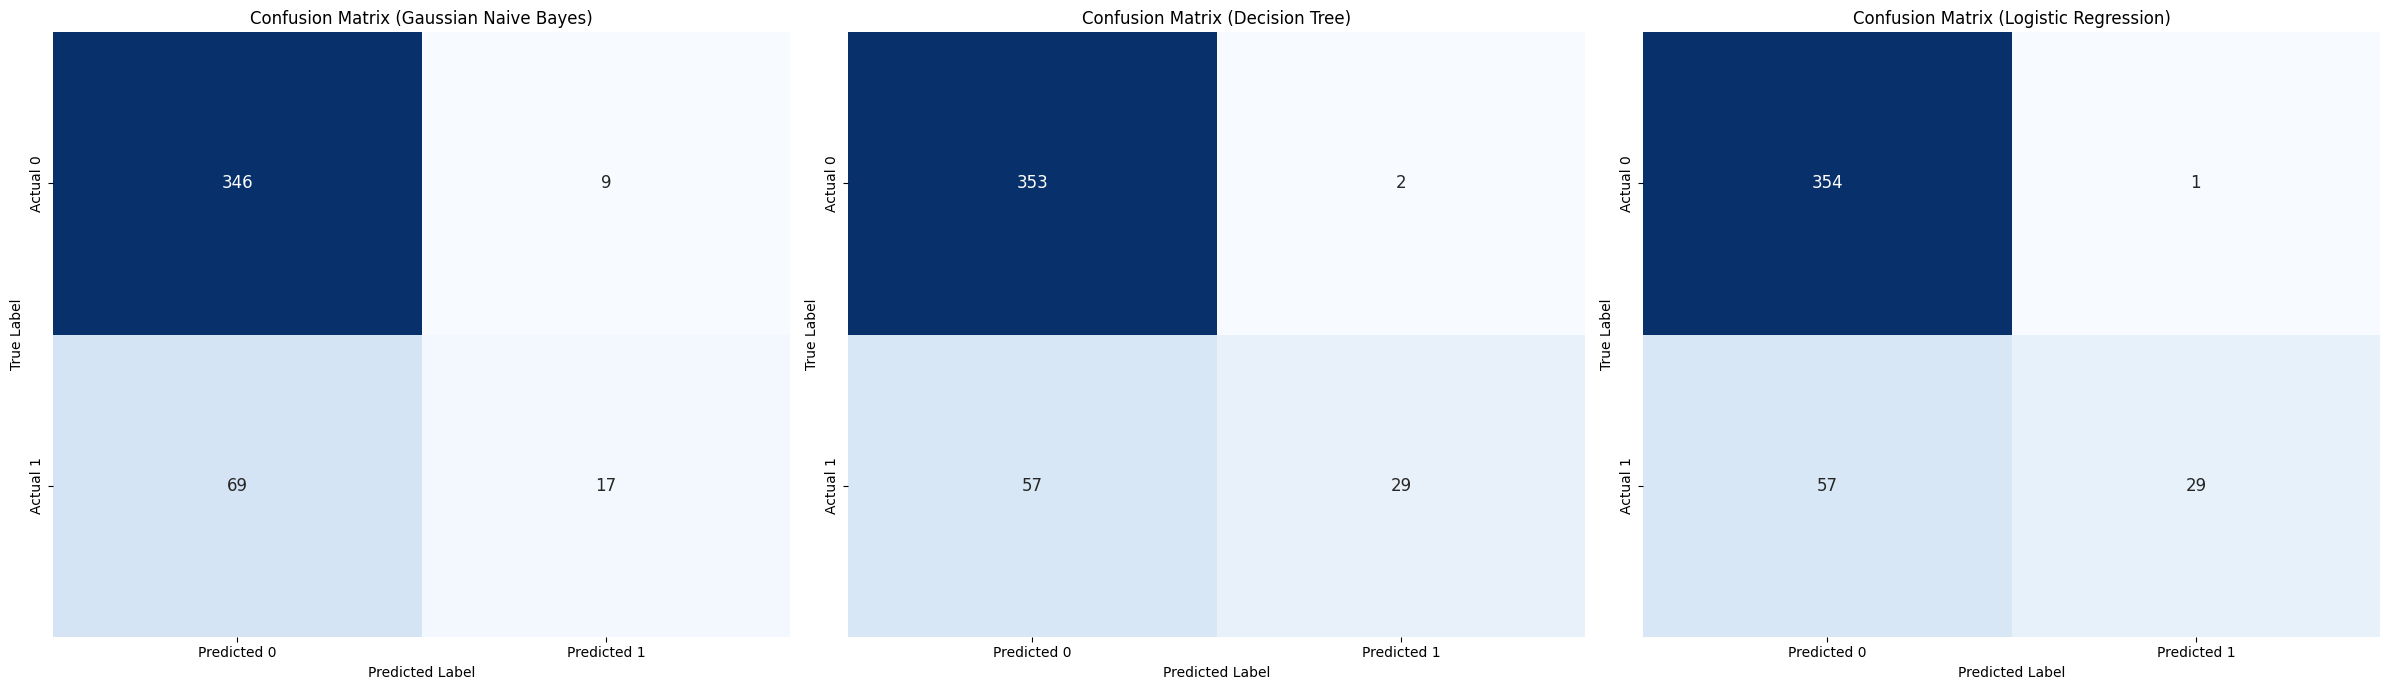

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrices for each model
cm_nb = confusion_matrix(y_test, y_pred) # y_pred is from GaussianNB
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Plot Confusion Matrix for Gaussian Naive Bayes
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[0],
            annot_kws={'fontsize': 'large'}) # Increased font size
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix (Gaussian Naive Bayes)')

# Plot Confusion Matrix for Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[1],
            annot_kws={'fontsize': 'large'}) # Increased font size
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix (Decision Tree)')

# Plot Confusion Matrix for Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[2],
            annot_kws={'fontsize': 'large'}) # Increased font size
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')
axes[2].set_title('Confusion Matrix (Logistic Regression)')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [29]:
from sklearn.metrics import confusion_matrix

def calculate_metrics(cm):
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]

    # Handle division by zero for sensitivity, precision, and F1-score
    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0.0

    # Calculate F1-score
    f1_score = (2 * precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) != 0 else 0.0

    return sensitivity, specificity, precision, f1_score

# Gaussian Naive Bayes Metrics
print("\n--- Gaussian Naive Bayes Metrics ---")
sensitivity_nb, specificity_nb, precision_nb, f1_nb = calculate_metrics(cm_nb)
print(f"민감도 (Sensitivity): {sensitivity_nb:.4f}")
print(f"특이도 (Specificity): {specificity_nb:.4f}")
print(f"정밀도 (Precision): {precision_nb:.4f}")
print(f"F1-score: {f1_nb:.4f}")

# Decision Tree Metrics
print("\n--- Decision Tree Metrics ---")
sensitivity_dt, specificity_dt, precision_dt, f1_dt = calculate_metrics(cm_dt)
print(f"민감도 (Sensitivity): {sensitivity_dt:.4f}")
print(f"특이도 (Specificity): {specificity_dt:.4f}")
print(f"정밀도 (Precision): {precision_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")

# Logistic Regression Metrics
print("\n--- Logistic Regression Metrics ---")
sensitivity_lr, specificity_lr, precision_lr, f1_lr = calculate_metrics(cm_lr)
print(f"민감도 (Sensitivity): {sensitivity_lr:.4f}")
print(f"특이도 (Specificity): {specificity_lr:.4f}")
print(f"정밀도 (Precision): {precision_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")



--- Gaussian Naive Bayes Metrics ---
민감도 (Sensitivity): 0.1977
특이도 (Specificity): 0.9746
정밀도 (Precision): 0.6538
F1-score: 0.3036

--- Decision Tree Metrics ---
민감도 (Sensitivity): 0.3372
특이도 (Specificity): 0.9944
정밀도 (Precision): 0.9355
F1-score: 0.4957

--- Logistic Regression Metrics ---
민감도 (Sensitivity): 0.3372
특이도 (Specificity): 0.9972
정밀도 (Precision): 0.9667
F1-score: 0.5000


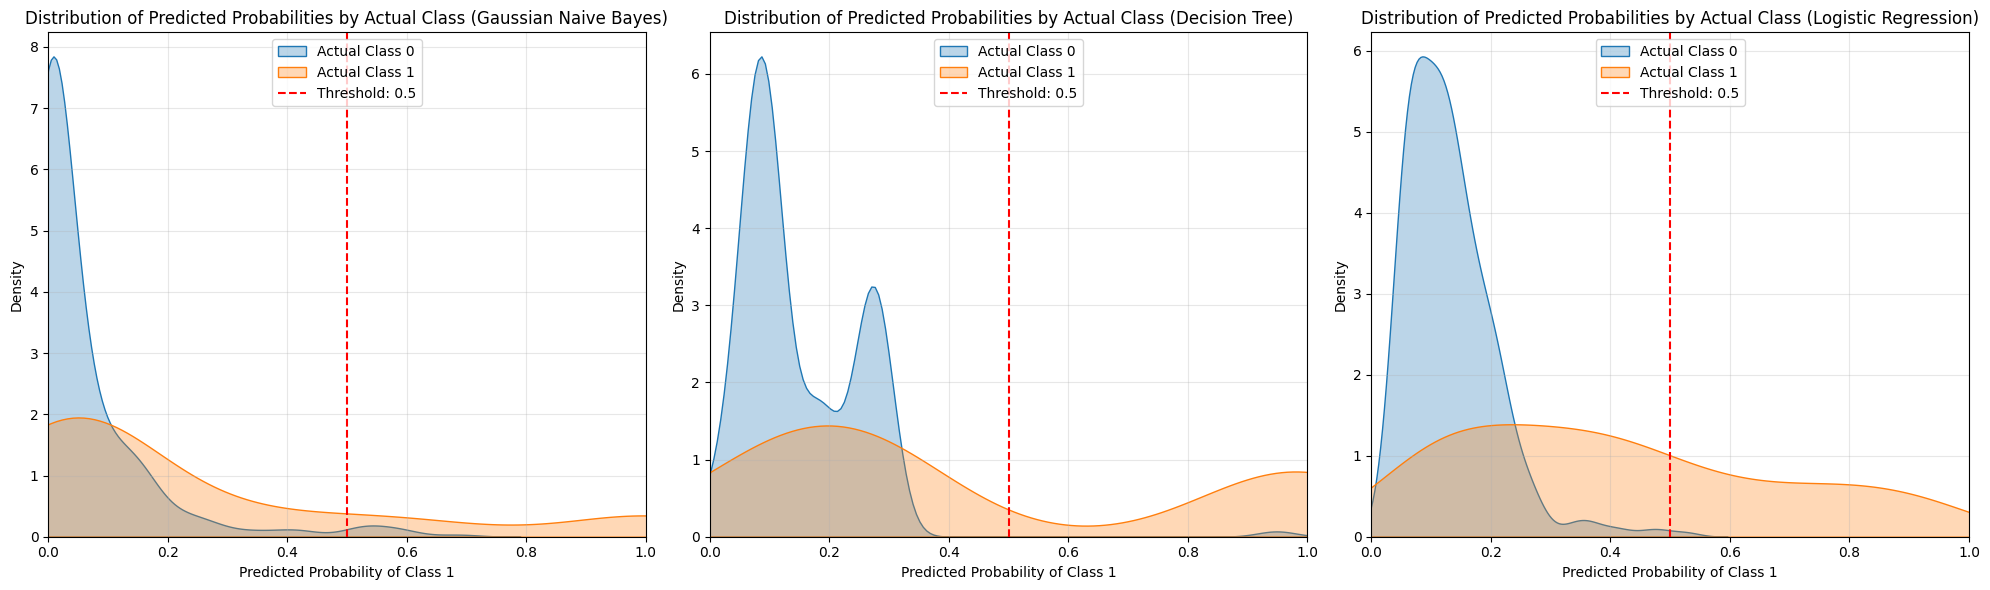

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare y_test as numpy array for consistent indexing
y_test_np = np.array(y_test)
threshold = 0.5

models = {
    "Gaussian Naive Bayes": nb_clf,
    "Decision Tree": dt_clf,
    "Logistic Regression": lr_clf
}

plt.figure(figsize=(20, 6))
for i, (name, model) in enumerate(models.items()):
    plt.subplot(1, 3, i + 1) # 1 row, 3 columns

    # Get predicted probabilities for Class 1
    prob_class_1 = model.predict_proba(X_test)[:, 1]

    # Plot distribution
    sns.kdeplot(prob_class_1[y_test_np == 0], label='Actual Class 0', fill=True, alpha=0.3)
    sns.kdeplot(prob_class_1[y_test_np == 1], label='Actual Class 1', fill=True, alpha=0.3)

    # Draw threshold line
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold: {threshold}')

    # Styling
    plt.xlabel('Predicted Probability of Class 1')
    plt.ylabel('Density')
    plt.title(f'Distribution of Predicted Probabilities by Actual Class ({name})')
    plt.xlim(0, 1)
    plt.legend(loc='upper center')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


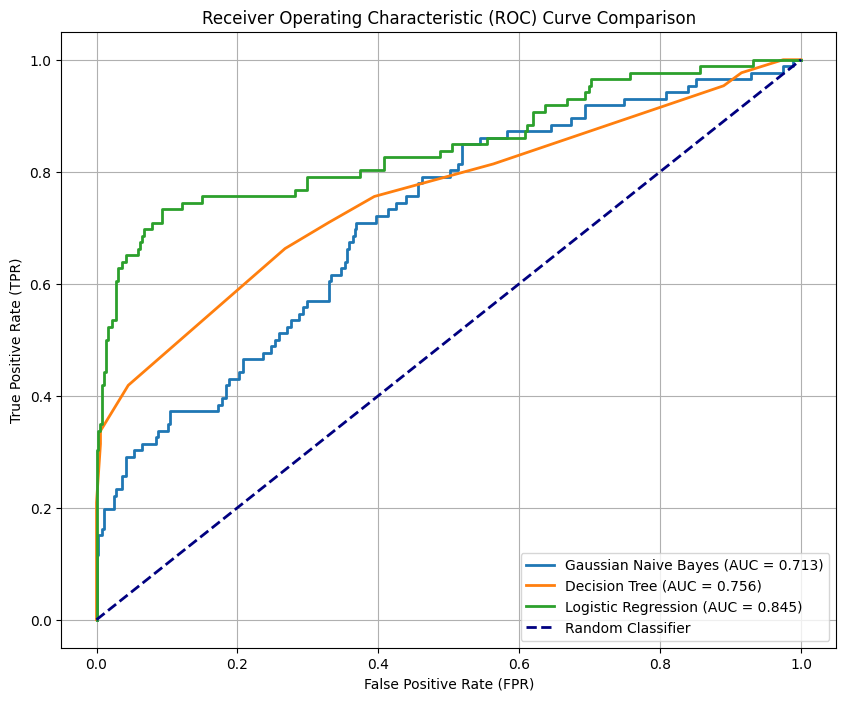

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models = {
    "Gaussian Naive Bayes": nb_clf,
    "Decision Tree": dt_clf,
    "Logistic Regression": lr_clf
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Get predicted probabilities for the positive class (class 1)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    # Calculate AUC score
    auc_score = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

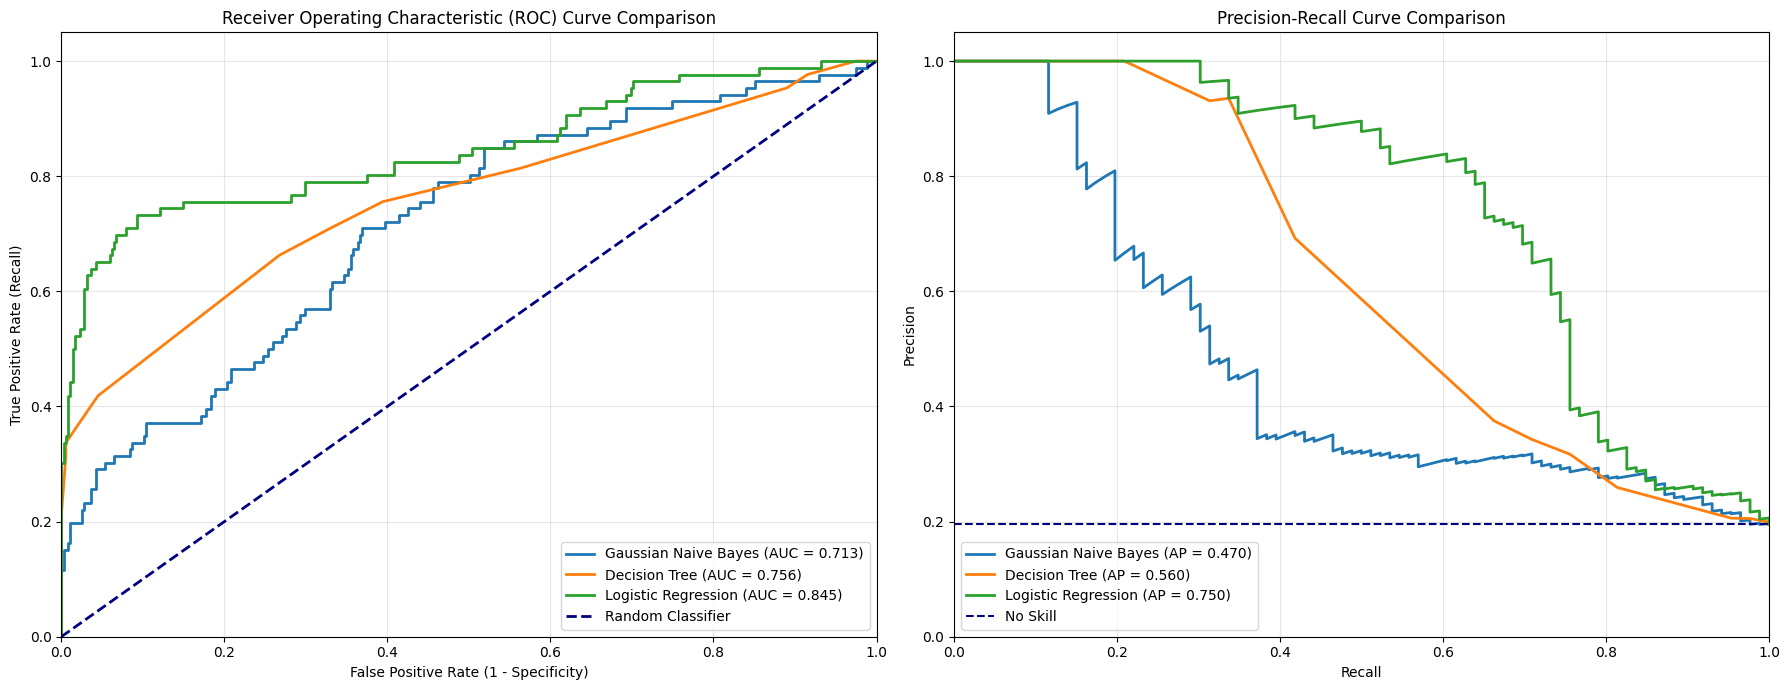

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

models = {
    "Gaussian Naive Bayes": nb_clf,
    "Decision Tree": dt_clf,
    "Logistic Regression": lr_clf
}

# Determine the no-skill line for PR curve
no_skill = len(y_test[y_test == 1]) / len(y_test)

# Create a figure with 1 row and 2 columns for ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot ROC Curves ---
for name, model in models.items():
    y_pred_proba_1 = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba_1)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve Comparison')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# --- Plot Precision-Recall Curves ---
for name, model in models.items():
    y_pred_proba_1 = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_1)
    ap_score = average_precision_score(y_test, y_pred_proba_1)
    axes[1].plot(recall, precision, lw=2, label=f'{name} (AP = {ap_score:.3f})')

axes[1].plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill', color='navy')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()